<a href="https://colab.research.google.com/github/ariandit/user_arian/blob/master/TAS_Metodologi_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalasi dependency (TensorFlow & OpenCV sudah tersedia di Colab)
!pip install -q imagehash

import os, sys, io, zipfile, hashlib, random, shutil
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42); np.random.seed(42)
print("Setup selesai. TensorFlow:", end=" ")
import tensorflow as tf
print(tf.__version__, "| GPU:", "AKTIF" if tf.config.list_physical_devices('GPU') else "TIDAK AKTIF (opsional, latihan lebih lambat)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.3 MB/s eta 0:00:00
Setup selesai. TensorFlow: 2.20.0 | GPU: TIDAK AKTIF (opsional, latihan lebih lambat)


In [ ]:
# Ekstrak zip
EXTRACT_DIR = "/content/dataset"
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Cari folder root dataset secara otomatis (folder yang berisi AC/LE/RP)
ROOT = None
for dp, dirs, _ in os.walk(EXTRACT_DIR):
    if {'AC','LE','RP'}.issubset(set(dirs)):
        ROOT = dp; break
assert ROOT, "Struktur folder AC/LE/RP tidak ditemukan!"
print("Root YOLO_Plate_Licens terdeteksi di:", ROOT)

Root YOLO_Plate_Licens terdeteksi di: /content/dataset/YOLO Plate License


Data Understanding

In [ ]:
def walk_jpgs(root):
    for dp, _, fs in os.walk(root):
        for f in fs:
            if f.lower().endswith(('.jpg', '.jpeg')):
                yield os.path.join(dp, f)

def parse_path(p, root):
    parts = os.path.relpath(p, root).split(os.sep)
    top   = parts[0]                       # AC / LE / RP
    char  = parts[1]                       # 0-9 / A-Z
    split = 'train' if 'train' in parts else ('test' if 'test' in parts else 'unknown')
    return top, char, split

# Bangun tabel inventaris lengkap
rows = []
for p in walk_jpgs(ROOT):
    top, char, split = parse_path(p, ROOT)
    rows.append({'path': p, 'top': top, 'char': char, 'split': split})

df = pd.DataFrame(rows)
print(f"Total berkas citra: {len(df):,}")
df.head()

Total berkas citra: 7,548


,path,top,char,split
0,/content/dataset/YOLO Plate License/LE/H/LE/te...,LE,H,test
1,/content/dataset/YOLO Plate License/LE/H/LE/te...,LE,H,test
2,/content/dataset/YOLO Plate License/LE/H/LE/te...,LE,H,test
3,/content/dataset/YOLO Plate License/LE/H/LE/te...,LE,H,test
4,/content/dataset/YOLO Plate License/LE/H/LE/te...,LE,H,test


In [ ]:
# 1.1 Distribusi per kategori sumber & split
print("=== Distribusi per kategori sumber (TOP) ===")
print(df['top'].value_counts(), "\n")

print("=== Komposisi train/test per kategori ===")
pivot = df.pivot_table(index='top', columns='split', values='path',
                       aggfunc='count', fill_value=0)
pivot['%test'] = (pivot.get('test',0) / pivot.sum(axis=1) * 100).round(1)
print(pivot)

=== Distribusi per kategori sumber (TOP) ===
top
LE    3935
AC    3409
RP     204
Name: count, dtype: int64 

=== Komposisi train/test per kategori ===
split  test  train  %test
top                      
AC     2896    513   85.0
LE     3466    469   88.1
RP      204      0  100.0


In [ ]:
# 1.2 Deteksi DUPLIKASI via hash MD5 isi berkas
def md5_of(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['md5'] = df['path'].map(md5_of)

n_files  = len(df)
n_unique = df['md5'].nunique()
n_dup    = n_files - n_unique
print(f"Total berkas       : {n_files:,}")
print(f"Foto UNIK (dedup)  : {n_unique:,}")
print(f"Berkas redundan    : {n_dup:,}  ({n_dup/n_files*100:.1f}% dari total)")

Total berkas       : 7,548
Foto UNIK (dedup)  : 1,463
Berkas redundan    : 6,085  (80.6% dari total)


In [ ]:
# 1.3 TEMUAN KUNCI — struktur folder karakter sebenarnya adalah anotasi MULTI-LABEL
# Satu foto (md5 sama) muncul di banyak folder karakter = daftar karakter pada plat itu.
multilabel = df.groupby('md5')['char'].apply(lambda s: sorted(set(s)))

chars_per_plate = multilabel.map(len)
print("Karakter unik per foto plat (proxy panjang plat):")
print(f"  min={chars_per_plate.min()}, max={chars_per_plate.max()}, "
      f"mean={chars_per_plate.mean():.2f}, median={int(chars_per_plate.median())}\n")

# contoh
ex_md5 = multilabel.index[0]
print("Contoh 1 foto ->", multilabel.iloc[0],
      f"({len(multilabel.iloc[0])} karakter)")

Karakter unik per foto plat (proxy panjang plat):
  min=2, max=6, mean=5.16, median=5

Contoh 1 foto -> ['1', '4', '7', 'D', 'L'] (5 karakter)


In [ ]:
# 1.4 Ketidakseimbangan kelas (imbalance)
char_counts = df['char'].value_counts()
order = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")
char_counts = char_counts.reindex(order, fill_value=0)

mx, mn = char_counts.max(), char_counts[char_counts>0].min()
print(f"Kelas terbanyak : '{char_counts.idxmax()}' = {mx}")
print(f"Kelas terlangka : '{char_counts[char_counts>0].idxmin()}' = {mn}")
print(f"Kelas kosong    : {list(char_counts[char_counts==0].index)}")
print(f"Rasio imbalance : {mx/mn:.1f}x")

Kelas terbanyak : '6' = 593
Kelas terlangka : 'I' = 9
Kelas kosong    : ['O']
Rasio imbalance : 65.9x


In [ ]:
# 1.5 Verifikasi integritas: data leakage & pemisahan sumber
# Apakah ada foto unik yang bocor lintas train & test?
split_per_md5 = df.groupby('md5')['split'].apply(lambda s: set(s))
leak = split_per_md5.map(lambda s: len(s) > 1).sum()
print(f"Foto unik bocor train<->test (data leakage): {leak}")

# Apakah kategori AC/LE/RP saling terpisah?
top_per_md5 = df.groupby('md5')['top'].apply(lambda s: set(s))
cross = top_per_md5.map(lambda s: len(s) > 1).sum()
print(f"Foto unik muncul di >1 kategori sumber      : {cross}")

Foto unik bocor train<->test (data leakage): 0
Foto unik muncul di >1 kategori sumber      : 0


Visualisasi Audit

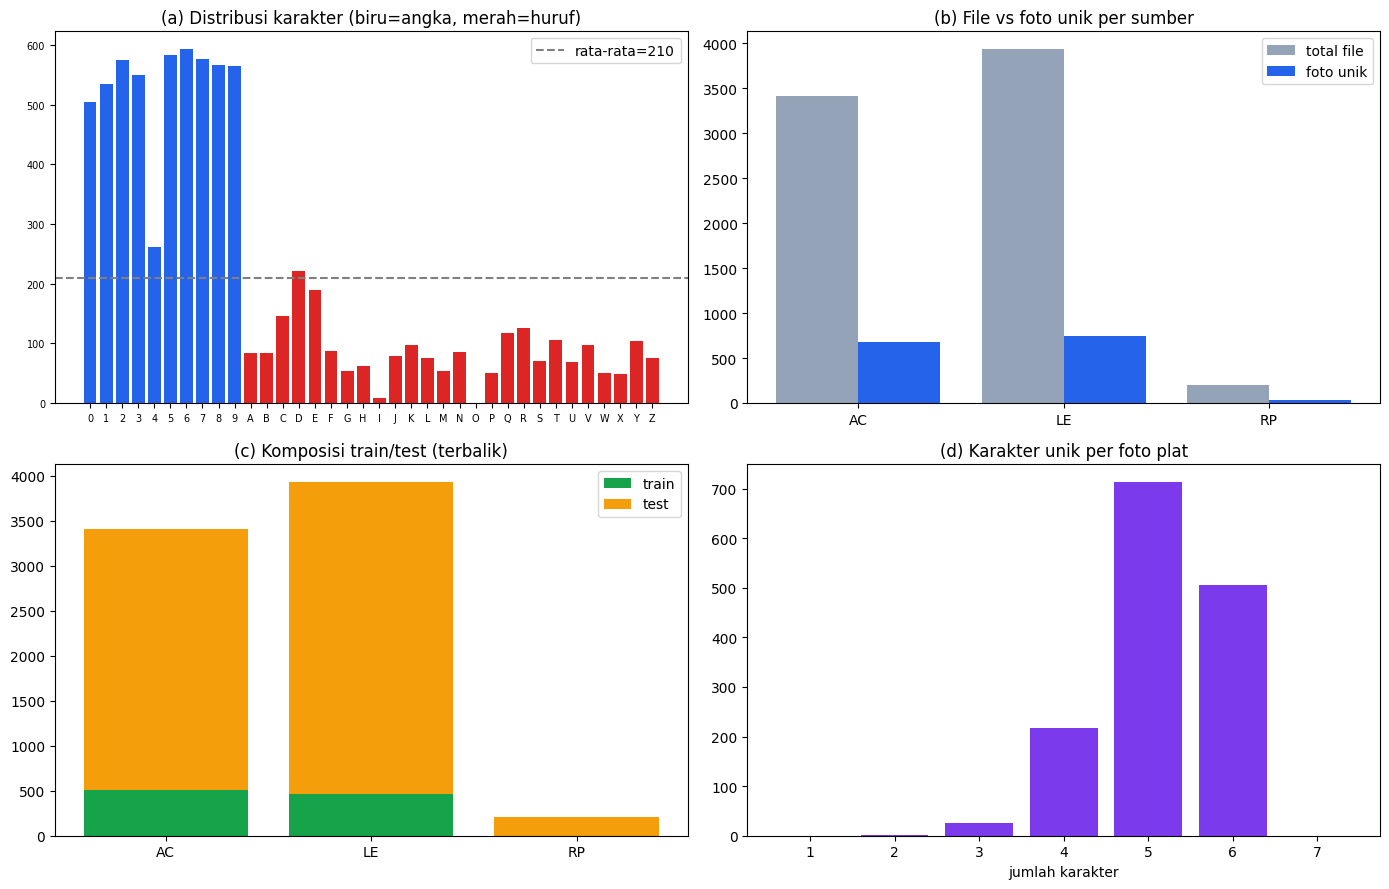

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) distribusi karakter
colors = ['#2563eb' if c.isdigit() else '#dc2626' for c in order]
axes[0,0].bar(order, char_counts.values, color=colors)
axes[0,0].axhline(char_counts.mean(), color='gray', ls='--',
                  label=f'rata-rata={char_counts.mean():.0f}')
axes[0,0].set_title('(a) Distribusi karakter (biru=angka, merah=huruf)')
axes[0,0].legend(); axes[0,0].tick_params(labelsize=7)

# (b) file vs unik per top
tops = ['AC','LE','RP']
files_c = [ (df['top']==t).sum() for t in tops ]
uniq_c  = [ df[df['top']==t]['md5'].nunique() for t in tops ]
x = np.arange(len(tops))
axes[0,1].bar(x-0.2, files_c, 0.4, label='total file', color='#94a3b8')
axes[0,1].bar(x+0.2, uniq_c, 0.4, label='foto unik', color='#2563eb')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(tops)
axes[0,1].set_title('(b) File vs foto unik per sumber'); axes[0,1].legend()

# (c) train/test terbalik
tr = [ ((df['top']==t)&(df['split']=='train')).sum() for t in tops ]
te = [ ((df['top']==t)&(df['split']=='test')).sum() for t in tops ]
axes[1,0].bar(tops, tr, label='train', color='#16a34a')
axes[1,0].bar(tops, te, bottom=tr, label='test', color='#f59e0b')
axes[1,0].set_title('(c) Komposisi train/test (terbalik)'); axes[1,0].legend()

# (d) panjang plat
axes[1,1].hist(chars_per_plate, bins=range(1,9), color='#7c3aed',
               align='left', rwidth=0.8)
axes[1,1].set_title('(d) Karakter unik per foto plat')
axes[1,1].set_xlabel('jumlah karakter')

plt.tight_layout(); plt.show()

### Ringkasan Temuan Audit

| Celah | Temuan | Risiko bila diabaikan |
|---|---|---|
| Duplikasi | ~81% berkas redundan | Metrik terlalu optimistis, model menghafal |
| Struktur multi-label tersamar | rata-rata ~5 karakter/plat | Salah merumuskan masalah sejak awal |
| Imbalance | hingga ~66× | Model rapuh pada huruf langka |
| Split terbalik | test 85–100% | Model kekurangan data latih |
| Sumber terpisah (AC/LE/RP) | tidak ada tumpang tindih | Peluang uji ketahanan lintas-domain |

### Temuan ini menjadi dasar seluruh langkah preparation berikut.

Data Preparation

In [ ]:
# 2.1 Deduplikasi + rekonstruksi anotasi multi-label
# Pilih SATU path perwakilan untuk tiap foto unik (md5), simpan label & metadata.
rep = (df.sort_values('path')
         .groupby('md5')
         .agg(path=('path','first'), top=('top','first'), split=('split','first'))
         .reset_index())

# label multi-label per md5
rep['labels'] = rep['md5'].map(multilabel)

print(f"Dataset unik: {len(rep)} foto plat")
rep.head(3)

Dataset unik: 1463 foto plat


,md5,path,top,split,labels
0,00062a8713fe15fb5c776995de9c0df7,/content/dataset/YOLO Plate License/AC/1/AC/te...,AC,test,"[1, 4, 7, D, L]"
1,000b7f83c99d0ddebc9daf4a15abceab,/content/dataset/YOLO Plate License/LE/3/LE/te...,LE,test,"[3, 5, 6, 7, E, Q]"
2,0041df2c02edb66af5d5e95273004f84,/content/dataset/YOLO Plate License/LE/0/LE/te...,LE,test,"[0, 1, 7, C, V]"


In [ ]:
# 2.2 Encode label ke vektor biner 36 kelas (0-9, A-Z)
CLASSES = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")
CLS2IDX = {c:i for i,c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

def encode(labels):
    v = np.zeros(NUM_CLASSES, dtype=np.float32)
    for c in labels:
        if c in CLS2IDX:
            v[CLS2IDX[c]] = 1.0
    return v

Y = np.stack(rep['labels'].map(encode).values)
print("Bentuk matriks label Y:", Y.shape, "(foto x kelas)")
print("Rata-rata karakter aktif/foto:", Y.sum(axis=1).mean().round(2))

Bentuk matriks label Y: (1463, 36) (foto x kelas)
Rata-rata karakter aktif/foto: 5.16


In [ ]:
# 2.3 Split ulang yang BENAR (80% train / 20% test), stratified-approx per sumber.
# Karena tidak ada leakage (1 md5 = 1 foto), split di level md5 aman.
from sklearn.model_selection import train_test_split

idx = np.arange(len(rep))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42,
    stratify=rep['top']  # jaga proporsi sumber AC/LE/RP di kedua sisi
)
print(f"Train: {len(train_idx)} foto | Test: {len(test_idx)} foto")
print("Proporsi sumber di train:\n", rep.iloc[train_idx]['top'].value_counts(normalize=True).round(2))

Train: 1170 foto | Test: 293 foto
Proporsi sumber di train:
 top
LE    0.51
AC    0.47
RP    0.02
Name: proportion, dtype: float64


In [ ]:
# 2.4 Pipeline pemuatan & augmentasi citra
IMG_SIZE = 128
BATCH = 32

def load_image(path, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    if augment:
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_ds(indices, augment=False, shuffle=False):
    paths  = rep.iloc[indices]['path'].values
    labels = Y[indices]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(indices), seed=42)
    ds = ds.map(lambda p, y: (load_image(p, augment), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_idx, augment=True,  shuffle=True)
test_ds  = make_ds(test_idx,  augment=False, shuffle=False)
print("Pipeline data siap.")

Pipeline data siap.


In [ ]:
# 2.5 Bobot kelas untuk melawan imbalance (kelas langka diberi bobot lebih besar)
pos = Y[train_idx].sum(axis=0)
pos = np.clip(pos, 1, None)  # hindari bagi nol
class_weight_vec = (len(train_idx) / (NUM_CLASSES * pos)).astype(np.float32)
class_weight_vec = np.clip(class_weight_vec, 0.5, 10.0)  # batasi ekstrem
print("Contoh bobot kelas (5 terkecil & terbesar frekuensinya):")
for i in list(np.argsort(pos)[:3]) + list(np.argsort(pos)[-3:]):
    print(f"  '{CLASSES[i]}': freq={int(pos[i])}, weight={class_weight_vec[i]:.2f}")

Contoh bobot kelas (5 terkecil & terbesar frekuensinya):
  'O': freq=1, weight=10.00
  'I': freq=9, weight=3.61
  'X': freq=34, weight=0.96
  '9': freq=465, weight=0.50
  '5': freq=468, weight=0.50
  '6': freq=474, weight=0.50


Modeling menggunakan CNN

In [ ]:
from tensorflow.keras import layers, models

def build_model():
    m = models.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='sigmoid')  # multi-label
    ])
    return m

# Loss berbobot untuk melawan imbalance
cw = tf.constant(class_weight_vec)
def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
    bce = -(y_true*tf.math.log(y_pred) + (1-y_true)*tf.math.log(1-y_pred))
    return tf.reduce_mean(bce * (1 + y_true*(cw-1)))

model = build_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=weighted_bce,
              metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True),
                       tf.keras.metrics.BinaryAccuracy(name='bin_acc', threshold=0.5)])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,516 (1.09 MB)

 Trainable params: 283,812 (1.08 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Pelatihan
EPOCHS = 25
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                     patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=3, min_lr=1e-5),
]
history = model.fit(train_ds, validation_data=test_ds,
                    epochs=EPOCHS, callbacks=callbacks)

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - auc: 0.4981 - bin_acc: 0.7980 - loss: 0.3717 - val_auc: 0.4887 - val_bin_acc: 0.8556 - val_loss: 0.2843 - learning_rate: 0.0010
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - auc: 0.5037 - bin_acc: 0.8545 - loss: 0.2459 - val_auc: 0.4728 - val_bin_acc: 0.8556 - val_loss: 0.2276 - learning_rate: 0.0010
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - auc: 0.5194 - bin_acc: 0.8557 - loss: 0.2374 - val_auc: 0.4804 - val_bin_acc: 0.8556 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - auc: 0.5289 - bin_acc: 0.8559 - loss: 0.2341 - val_auc: 0.4790 - val_bin_acc: 0.8556 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - auc: 0.5294 - bin_acc: 0.8562 - loss: 0.2315 - val_auc: 0.4740 - val_bin_acc: 0.8556 - val_loss: 0.2297 - learning_rate: 0.0010
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - auc: 0.5339 - bin_acc: 0.8565 - loss: 0.2303 - v

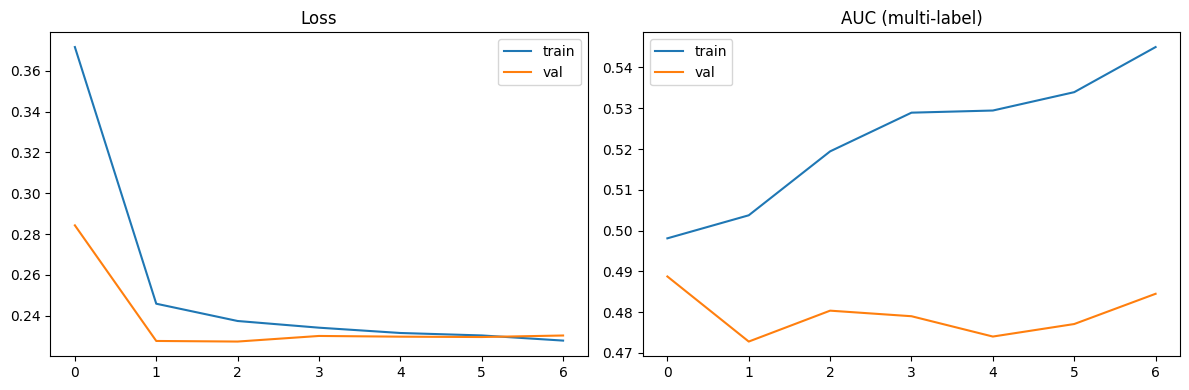

In [ ]:
# Kurva pelatihan
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(h['auc'], label='train'); ax[1].plot(h['val_auc'], label='val')
ax[1].set_title('AUC (multi-label)'); ax[1].legend()
plt.tight_layout(); plt.show()

Evaluation ( dua tingkat )

In [ ]:
# 4.1 Prediksi pada test set
y_true = Y[test_idx]
y_prob = model.predict(test_ds)
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss
print("=== TINGKAT 1: Kinerja teknis (per-karakter, multi-label) ===")
print(f"F1  (micro) : {f1_score(y_true, y_pred, average='micro', zero_division=0):.3f}")
print(f"F1  (macro) : {f1_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
print(f"Precision   : {precision_score(y_true, y_pred, average='micro', zero_division=0):.3f}")
print(f"Recall      : {recall_score(y_true, y_pred, average='micro', zero_division=0):.3f}")
print(f"Hamming loss: {hamming_loss(y_true, y_pred):.3f}  (makin kecil makin baik)")

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 692ms/step
=== TINGKAT 1: Kinerja teknis (per-karakter, multi-label) ===
F1  (micro) : 0.000
F1  (macro) : 0.000
Precision   : 0.000
Recall      : 0.000
Hamming loss: 0.144  (makin kecil makin baik)


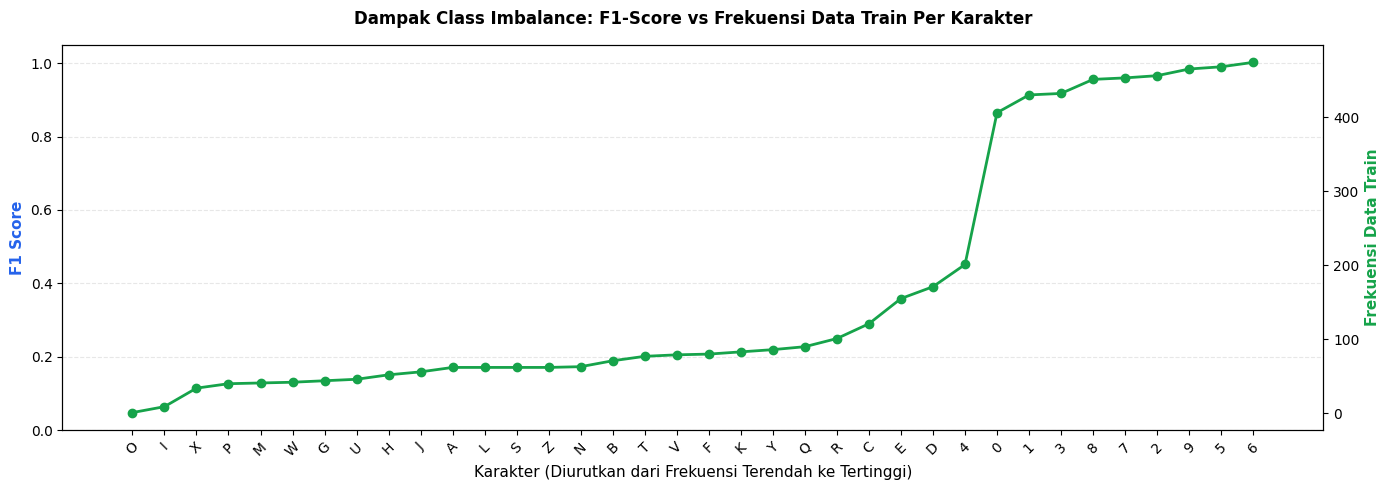

Korelasi frekuensi vs F1: nan (positif = kelas langka cenderung lebih lemah -> efek imbalance)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# 1. Hitung F1-score per kelas
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

# 2. Buat DataFrame & urutkan berdasarkan frekuensi data train
dfk = pd.DataFrame({
    'char': CLASSES,
    'f1': per_class_f1,
    'freq_train': pos.astype(int)
}).sort_values('freq_train').reset_index(drop=True)

# 3. Plotting Dual Axis
fig, ax1 = plt.subplots(figsize=(14, 5))

# Sumbu Y Kiri: F1-Score (Bar Chart)
colors = ['#dc2626' if f < 0.3 else '#2563eb' for f in dfk['f1']]
bars = ax1.bar(dfk['char'], dfk['f1'], color=colors, alpha=0.7, label='F1-Score')
ax1.set_ylabel('F1 Score', color='#2563eb', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Karakter (Diurutkan dari Frekuensi Terendah ke Tertinggi)', fontsize=11)
ax1.tick_params(axis='x', rotation=45) # Rotasi label agar tidak bertumpuk
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Sumbu Y Kanan: Frekuensi Train (Line Chart)
ax2 = ax1.twinx()
ax2.plot(dfk['char'], dfk['freq_train'], color='#16a34a', marker='o', linewidth=2, label='Frekuensi Train')
ax2.set_ylabel('Frekuensi Data Train', color='#16a34a', fontsize=11, fontweight='bold')

# Judul & Lay out
plt.title('Dampak Class Imbalance: F1-Score vs Frekuensi Data Train Per Karakter', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# 4. Cetak Hasil Korelasi
corr = np.corrcoef(dfk['freq_train'], dfk['f1'])[0, 1]
print(f"Korelasi frekuensi vs F1: {round(corr, 3)} (positif = kelas langka cenderung lebih lemah -> efek imbalance)")

In [ ]:
# 4.3 TINGKAT 2: Uji ketahanan lintas-sumber (bias antar-domain AC/LE/RP)
print("=== TINGKAT 2: Kesesuaian tujuan — F1 micro per sumber ===")
test_rep = rep.iloc[test_idx].reset_index(drop=True)
for t in ['AC','LE','RP']:
    mask = (test_rep['top']==t).values
    if mask.sum()==0:
        print(f"  {t}: (tidak ada sampel di test)"); continue
    f1t = f1_score(y_true[mask], y_pred[mask], average='micro', zero_division=0)
    print(f"  {t}: F1={f1t:.3f}  (n={mask.sum()})")
print("\nJika selisih antar-sumber besar -> model bias terhadap domain tertentu,")
print("mengingatkan pada kasus 'standar nasional vs daerah': solusi harus adil lintas-konteks.")

=== TINGKAT 2: Kesesuaian tujuan — F1 micro per sumber ===
  AC: F1=0.000  (n=136)
  LE: F1=0.000  (n=149)
  RP: F1=0.000  (n=8)

Jika selisih antar-sumber besar -> model bias terhadap domain tertentu,
mengingatkan pada kasus 'standar nasional vs daerah': solusi harus adil lintas-konteks.


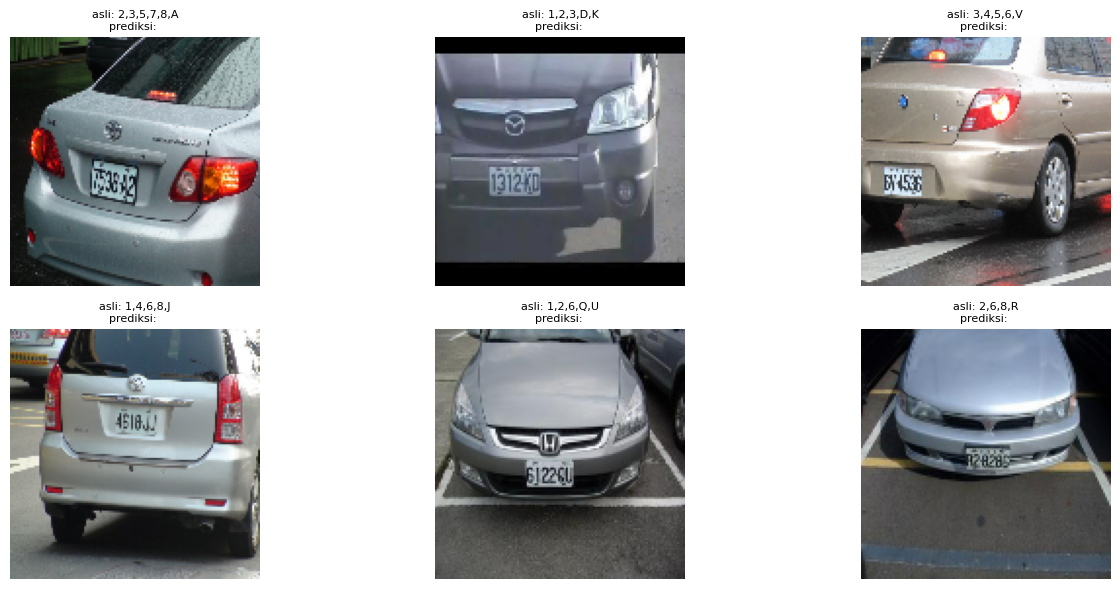

In [ ]:
# 4.4 Contoh prediksi kualitatif
import matplotlib.pyplot as plt
sample = np.random.choice(test_idx, 6, replace=False)
plt.figure(figsize=(14,6))
for i, s in enumerate(sample):
    img = load_image(rep.iloc[s]['path']).numpy()
    prob = model.predict(img[None], verbose=0)[0]
    pred = [CLASSES[j] for j in np.where(prob>=0.5)[0]]
    true = rep.iloc[s]['labels']
    plt.subplot(2,3,i+1); plt.imshow(img); plt.axis('off')
    plt.title(f"asli: {','.join(true)}\nprediksi: {','.join(pred)}", fontsize=8)
plt.tight_layout(); plt.show()

## Penutup

Menuntaskan siklus CRISP-DM dari audit hingga evaluasi. Poin penting yang ditegaskan kode ini:

- **Deduplikasi wajib** sebelum modeling — tanpa itu, metrik akan menyesatkan.
- **Struktur data sebenarnya multi-label**, bukan klasifikasi karakter tunggal.
- **Imbalance ditangani** lewat bobot kelas, dan dampaknya terlihat pada F1 per-kelas.
- **Evaluasi dua tingkat**: kinerja teknis + kesesuaian tujuan (uji bias lintas-sumber).

**Catatan pengembangan lanjutan:** untuk sistem ANPR produksi, tahap berikutnya adalah *deteksi lokasi plat* (mis. YOLO) lalu *pengenalan urutan karakter* (CRNN/CTC) pada plat yang sudah terpotong — pendekatan yang lebih sesuai daripada klasifikasi multi-label pada citra kendaraan penuh, namun menuntut anotasi bounding box yang tidak tersedia pada dataset ini.
